# 0. Setup

## 0.1. Libraries

In [57]:
# pip install tifffile

In [58]:
# General utilities
import os
import pandas as pd
import numpy as np
import torch
from pathlib import Path
from collections import defaultdict
import warnings 
warnings.filterwarnings("ignore")

# Image processing
from PIL import Image
import tifffile

# Custom library
from library.eda.eda import DataExplorer
from library.visualizations.indices_visualizer import IndicesVisualizer
from library.utilities.build_path_dictionary import build_path_dictionary

from library.utilities.read_png_to_numpy import read_png_to_numpy
from library.utilities.read_tiff_to_numpy import read_tiff_to_numpy
from library.utilities.read_png_to_torch import read_png_to_torch
from library.utilities.read_tiff_to_torch import read_tiff_to_torch

## 0.2. Paths and initialization of variables

In [59]:
# input_labelled_dir = '/media/pablo/Shared files/data/Satellite_burned_area_dataset'  # Adjust this path as needed
# input_inference_dir = os.path.join('..', 'catalunya_fire_imgs')

In [60]:
# input_dir = '/media/pablo/Shared files/data/Satellite_burned_area_dataset'  # Adjust this path as needed
input_dir = 'C:/Users/blanc/OneDrive/Desktop/DSDM/3-ImageProcessing/FINAL_HW/'

tiles_path = os.path.join(input_dir, 'tiled_labelled_dataset')
full_images_path = os.path.join(input_dir, 'Satellite_burned_area_dataset')

tiles_dict = build_path_dictionary(tiles_path)
full_images_dict = build_path_dictionary(full_images_path)

In [61]:
# CHECK DICTIONARIES
print("------------ Tiles Dictionary: ------------")
for key, paths in tiles_dict.items():
    print(f"{key}: {len(paths)} files")
    if paths:  # Show first few examples
        print(f"  Examples: {paths[:3]}")
    for path in paths:
        if Path(path).exists() == False:
            print(f"  !!! Wrong path: {path}")
    print()

print("------------ Full Images Dictionary: ------------")
for key, paths in full_images_dict.items():
    print(f"{key}: {len(paths)} files")
    if paths:  # Show first few examples
        print(f"  Examples: {paths[:3]}")
    for path in paths:
        if Path(path).exists() == False:
            print(f"  !!! Wrong path: {path}")
    print()

------------ Tiles Dictionary: ------------
coverages: 6010 files
  Examples: ['C:/Users/blanc/OneDrive/Desktop/DSDM/3-ImageProcessing/FINAL_HW/tiled_labelled_dataset\\EMSR207_01MIRANDADOCORVO_02GRADING_MAP_v2_vector\\coverages\\sentinel1_2017-07-01_coverage_tile_0_0.png', 'C:/Users/blanc/OneDrive/Desktop/DSDM/3-ImageProcessing/FINAL_HW/tiled_labelled_dataset\\EMSR207_01MIRANDADOCORVO_02GRADING_MAP_v2_vector\\coverages\\sentinel1_2017-07-01_coverage_tile_0_1.png', 'C:/Users/blanc/OneDrive/Desktop/DSDM/3-ImageProcessing/FINAL_HW/tiled_labelled_dataset\\EMSR207_01MIRANDADOCORVO_02GRADING_MAP_v2_vector\\coverages\\sentinel1_2017-07-01_coverage_tile_0_2.png']

masks: 3230 files
  Examples: ['C:/Users/blanc/OneDrive/Desktop/DSDM/3-ImageProcessing/FINAL_HW/tiled_labelled_dataset\\EMSR207_01MIRANDADOCORVO_02GRADING_MAP_v2_vector\\masks\\EMSR207_01MIRANDADOCORVO_02GRADING_MAP_v2_vector_mask_tile_0_0.tiff', 'C:/Users/blanc/OneDrive/Desktop/DSDM/3-ImageProcessing/FINAL_HW/tiled_labelled_dataset\

## 0.3. Notebook description

In this notebook we preprocess the image data to prepare it for training/validation/test and for inference. To that end, we pre-process 2 different sources of data:
1) The labelled dataset from *Luca Colomba, Alessandro Farasin, Simone Monaco, Salvatore Greco, Paolo Garza, Daniele Apiletti, Elena Baralis, and Tania Cerquitelli. 2022. A Dataset for Burned Area Delineation and Severity Estimation from Satellite Imagery. In Proceedings of the 31st ACM International Conference on Information & Knowledge Management (CIKM '22). Association for Computing Machinery, New York, NY, USA, 3893–3897. https://doi.org/10.1145/3511808.3557528*. The dataset can be downloaded from here: https://zenodo.org/records/6597139 (click on "Download all", which will approximately download 14GB worth of images and labels).
2) The inference dataset for the fires in Catalunya, obtained by our own means through the APIs of [Sentinel Hub](https://dataspace.copernicus.eu/analyse/apis/sentinel-hub) (see the notebooks for part 1). 

To that end, in this notebook we follow the the pre-processing steps outlined in the paper (for consistency):
  1) Since our research question focuses on assessing the severity of fires in Catalunya (inference), we will only be using the post-fire satellite imagery (like the authors do for their binary segmentation task).
  2) Generate 512x512 pixel tiles for the labelled train, validation, test and inference data. For images whose size is not a multiple of 512, overlap of tiles is allowed (in order to cover all of the area of the image). 
  3) Additionally, during the training phase, we will randomly shuffle the tiles and apply data augmentation techniques (see the corresponding training notebook).

> The final goal is to train a model that estimates the severity of a wildfire using post-wildfire (1 month after) imagery, and then to run inference with the satellite images from wildfires in Catalunya in the last decade. Severity estimation will be done at the pixel level.

Additionally, within the paper, the authors of the dataset provide additional metadata and a suggestion for the organization of the folds for training/validation:

# 1. Pre-processing the labelled data

"Annotations released by Copernicus specify 5 different severity levels, which were encoded in a greyscale image in range [0 − 255], from no damage to completely destroyed area." Labels have 5 levels of severity (0 = undamaged to 4 = fully destroyed).

Such classes are highly imbalanced: unburnt areas are the 91.9% of the whole images. Focusing on burnt areas only, class 1 covers around the 12%, while class 2 to 4 coverages stay around 30% (1%, 2.25%, 2.35%, and 2.5% of the total, respectively for the 4 classes).

In [62]:
print('CHANNELS:')
for key in tiles_dict.keys():
    photo = tiles_dict[key][0]  # Get the first photo path for each key
    try:
        print(f'{key:<9}: {read_tiff_to_numpy(photo).shape}')
    except Exception:
        print(f'{key:<9}: {read_png_to_numpy(photo).shape}')


CHANNELS:
coverages: (1, 256, 256)
masks    : (1, 256, 256)
sentinel1: (4, 256, 256)
sentinel2: (13, 256, 256)


Value 0.0  : 173,585,187 pixels (82.00 %)
Value 32.0 :  19,472,614 pixels ( 9.20 %)
Value 64.0 :   2,091,118 pixels ( 0.99 %)
Value 128.0:   5,325,971 pixels ( 2.52 %)
Value 192.0:   5,598,256 pixels ( 2.64 %)
Value 255.0:   5,608,134 pixels ( 2.65 %)

Images with only negative pixels: 2022 (62.60%)


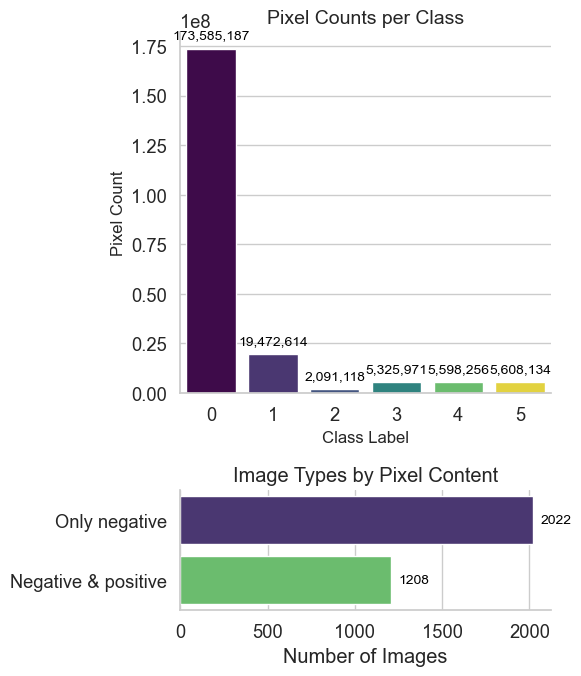

In [63]:
eda = DataExplorer(tiles_dict)

eda.count_mask_pixels()
eda.visualize_mask_pixels()

We see 6 different classes, but the authors specify that they are using only 5 and that they are following the [Copernicus Fire Severity](https://forest-fire.emergency.copernicus.eu/about-effis/technical-background/fire-severity) convention to do the classification, so we decide to respect that and regroup the pixels accordingly. That is, we will transfer the pixels in class 1 to class 2 (as we keep the pixel value of class 2, 64.0). This new joint group will become class one and classes 3, 4, 5 will become 2, 3, and 4.

Class 0                   : 193,057,801 pixels (91.20 %)
Class 1                   :   2,091,118 pixels ( 0.99 %)
Class 2                   :   5,325,971 pixels ( 2.52 %)
Class 3                   :   5,598,256 pixels ( 2.64 %)
Class 4                   :   5,608,134 pixels ( 2.65 %)

Images with only unburned pixels: 2290 (70.90%)


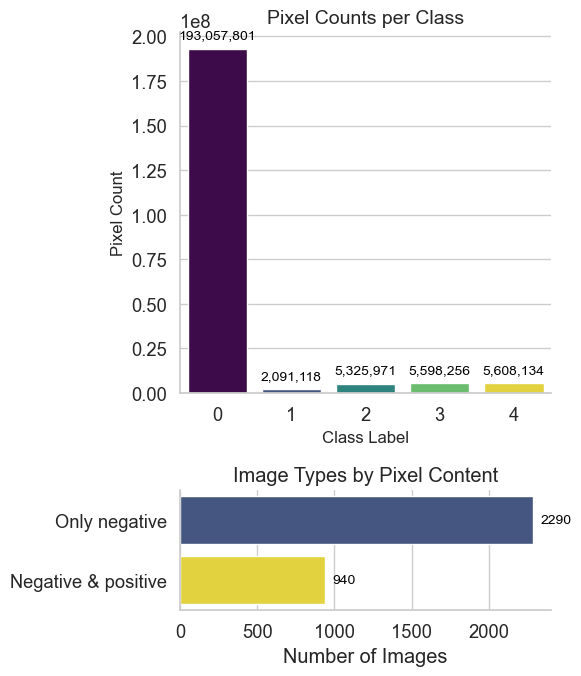

In [8]:
eda.count_regrouped_mask_pixels(map_to_classes=True)
eda.visualize_mask_pixels()

In [9]:
# eda.count_coverage_pixels()
# eda.visualize_coverage_pixels()

There are 90, out of the 6,209 tiles, counting Sentinel-1 and Sentinel-2 tiles, with defective pixels. Out of the tiles with any defective pixels, 70% the pixels are defective. Because of this and the high availability of data, we delete all the tiles that have defective pixels. For each tile that we delete, we delete the corresponding mask and the corresponding tile for the other satellite.

In [10]:
black_list = eda.defective_coverages_path_list

In [11]:
# black_list = eda.defective_coverages_path_list
# print('NUMBER OF DEFECTIVE COVERAGES:', len(black_list))

# print('\nFIRST 10 DEFECTIVE COVERAGES:')
# black_list[:10]

In [12]:
for p in black_list:
    f = os.path.splitext(os.path.basename(p))[0]
    parts = f.split('_')

    tile_id = '_' + '_'.join(parts[-3:])  # '_tile_2_9'

    path = Path(p)

    parent_folder = path.parent.parent
    
    # Go through all subdirectories (coverages, masks, images)
    for subdir in parent_folder.iterdir():
        if subdir.is_dir():
            
            # Look for files containing the tile_id in their filename
            for file in subdir.iterdir():
                if file.is_file() and tile_id in file.name:
                    try:
                        file.unlink()  # Delete the file
                    except Exception as e:
                        print(f"    ✗ Error deleting {file.name}: {e}")
    
print(f"All faulty images deleted ✓")

All faulty images deleted ✓


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0095999995..1.1223].


Selected image: C:/Users/blanc/OneDrive/Desktop/DSDM/3-ImageProcessing/FINAL_HW/tiled_labelled_dataset\EMSR207_03PAMPILHOSADASERRA_02GRADING_MAP_v2_vector\images\sentinel2_2017-07-04_tile_4_0.tiff


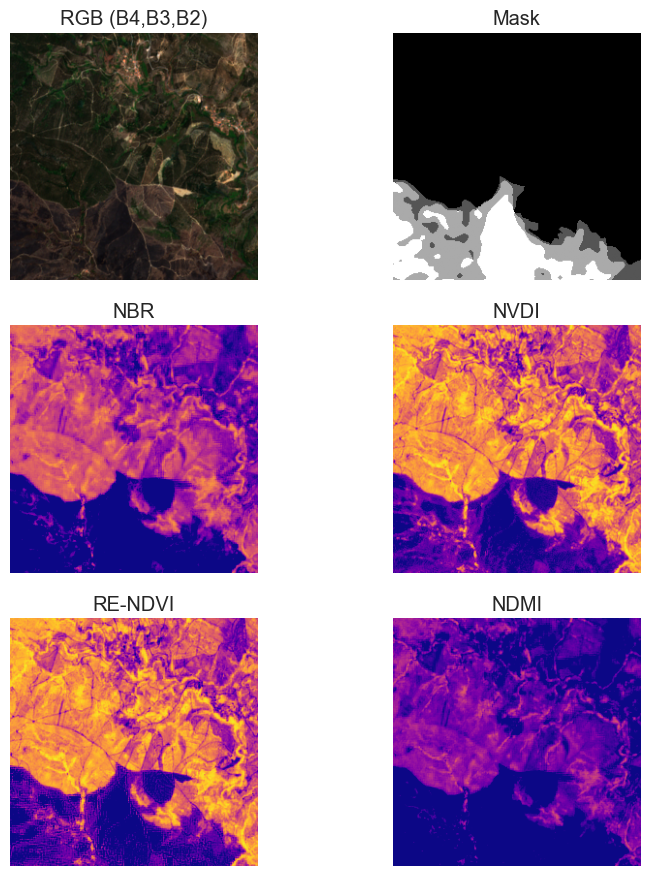

In [55]:
import random

# Get a random Sentinel-2 image path
sentinel2_paths = tiles_dict.get('sentinel2', [])
if not sentinel2_paths:
    print("No Sentinel-2 images found in tiles_dict")
else:
    # Select a random image
    img_path = random.choice(sentinel2_paths)
    print(f"Selected image: {img_path}")
    
    # Extract the fire_id and tile_id from the path to find the matching mask
    img_filename = os.path.basename(img_path)
    img_dir = os.path.dirname(img_path)
    fire_folder = os.path.basename(os.path.dirname(os.path.dirname(img_path)))
    
    # The tile identifier is typically the last part of the filename
    # e.g., sentinel2_tile_0_0.tiff -> tile_0_0
    tile_id = '_'.join(img_filename.split('_')[-3:]).replace('.tiff', '')
    
    # Find the mask in the same fire folder with the same tile ID
    mask_paths = tiles_dict.get('masks', [])
    matching_masks = [mask for mask in mask_paths if 
                     fire_folder in mask and 
                     tile_id in os.path.basename(mask)]
    
    if matching_masks:
        mask_path = matching_masks[0]
    else:
        print(f"No matching mask found for tile_id: {tile_id} in fire folder: {fire_folder}")

train_visualizer = IndicesVisualizer(img_path, mask_path)
train_visualizer.visualize_indices()

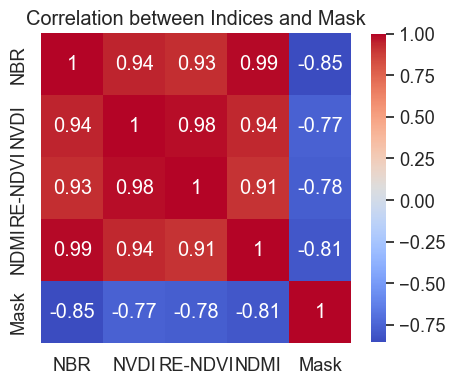

In [56]:
train_visualizer.visualize_correlations()

Sampling 10000 pixels from up to 50 Sentinel-2 images...


Processing Sentinel-2 images: 100%|██████████| 50/50 [00:02<00:00, 17.17it/s]


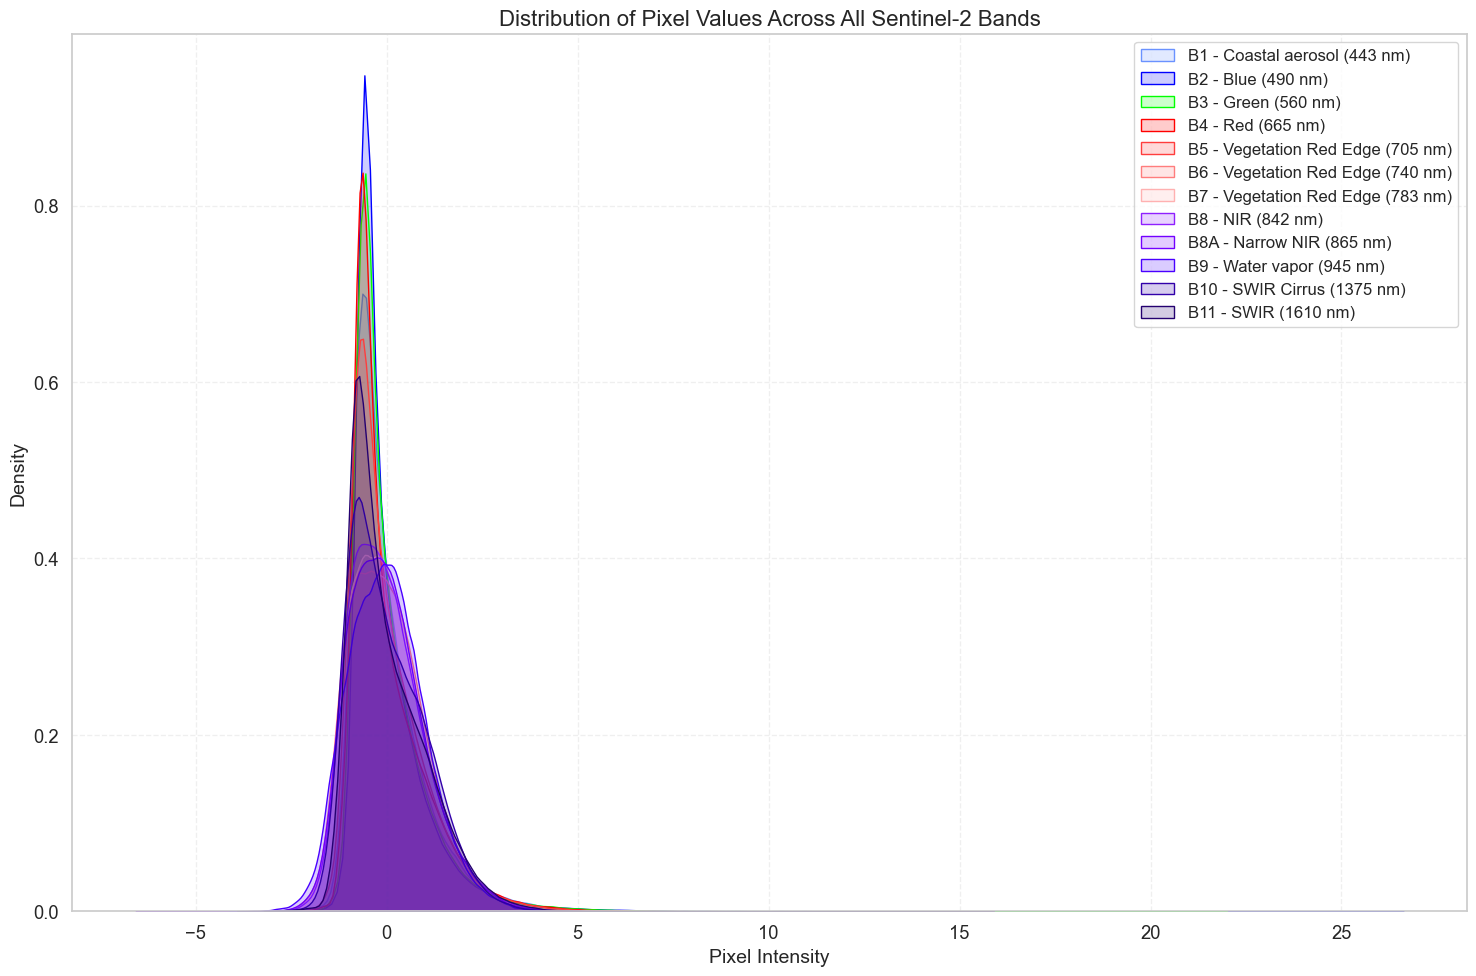

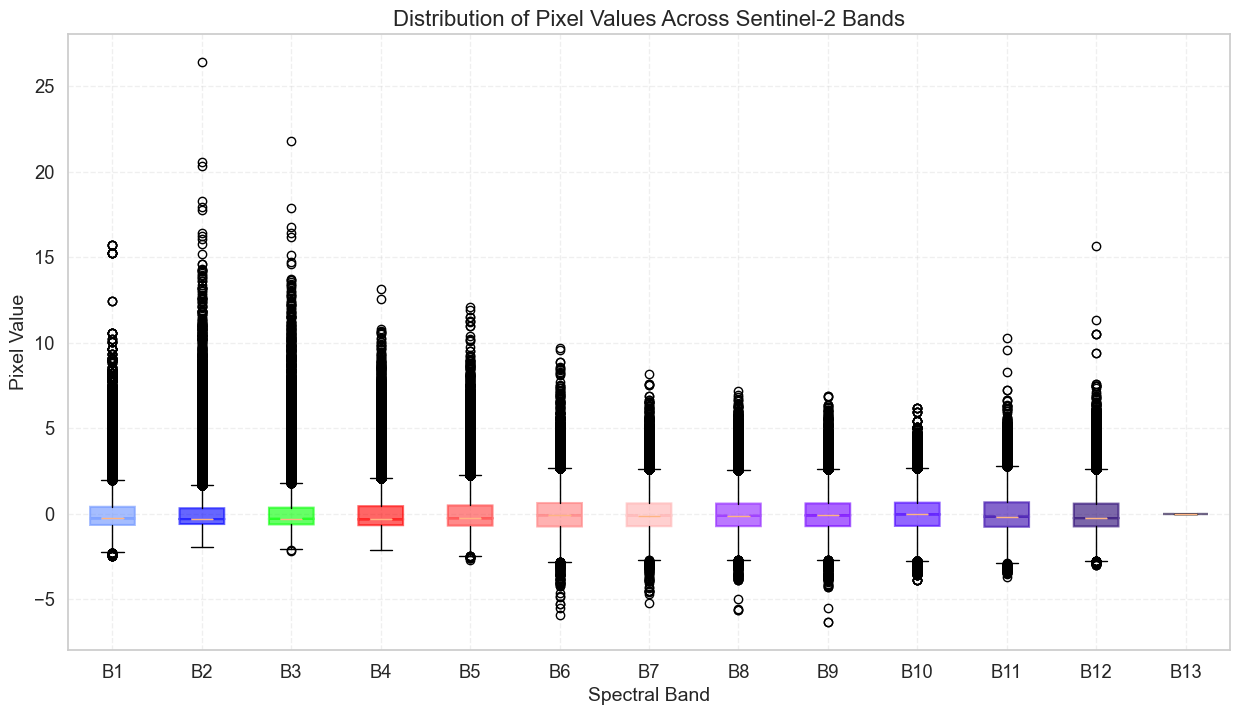

In [64]:
eda.plot_sentinel2_bands_distribution()